In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.metrics import confusion_matrix

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

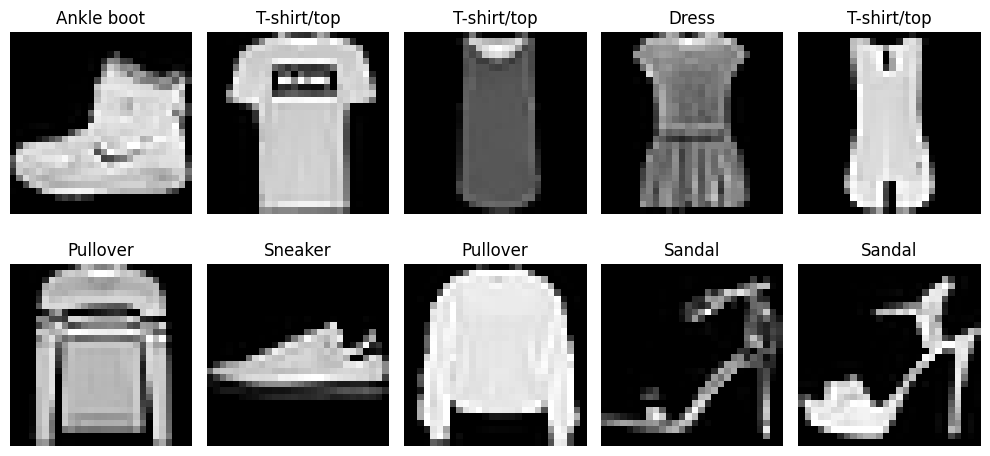

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [6]:
x_validation = x_train[-6000:]
y_validation = y_train[-6000:]

x_train_final = x_train[:-6000]
y_train_final = y_train[:-6000]

print("Training data:", x_train_final.shape)
print("Validation data:", x_validation.shape)
print("Test data:", x_test.shape)

Training data: (54000, 28, 28)
Validation data: (6000, 28, 28)
Test data: (10000, 28, 28)


In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train_final,
    y_train_final,
    epochs=10,
    batch_size=32,
    validation_data=(x_validation, y_validation)
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8233 - loss: 0.5006 - val_accuracy: 0.8510 - val_loss: 0.4172
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8654 - loss: 0.3705 - val_accuracy: 0.8628 - val_loss: 0.3799
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8782 - loss: 0.3339 - val_accuracy: 0.8715 - val_loss: 0.3470
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8843 - loss: 0.3125 - val_accuracy: 0.8722 - val_loss: 0.3484
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8901 - loss: 0.2940 - val_accuracy: 0.8752 - val_loss: 0.3472
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8959 - loss: 0.2801 - val_accuracy: 0.8823 - val_loss: 0.3290
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9008 - loss: 0.2684 - val_accuracy: 0.8808 - val_loss: 0.3287
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9035 - loss: 0.2584 -

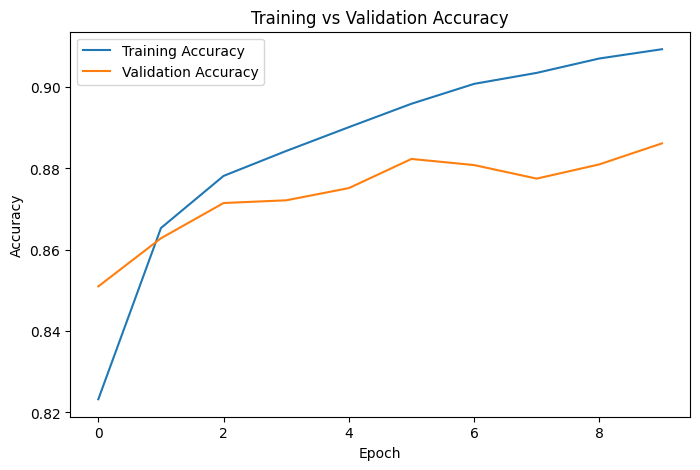

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

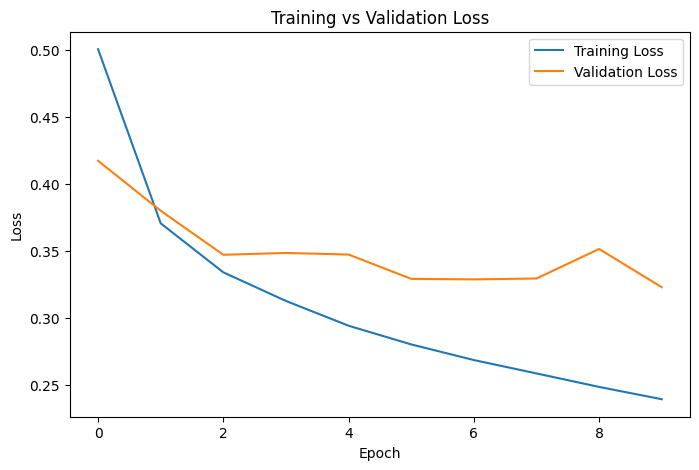

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.3340
Test Loss: 0.333986759185791
Test Accuracy: 0.8816999793052673


In [13]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


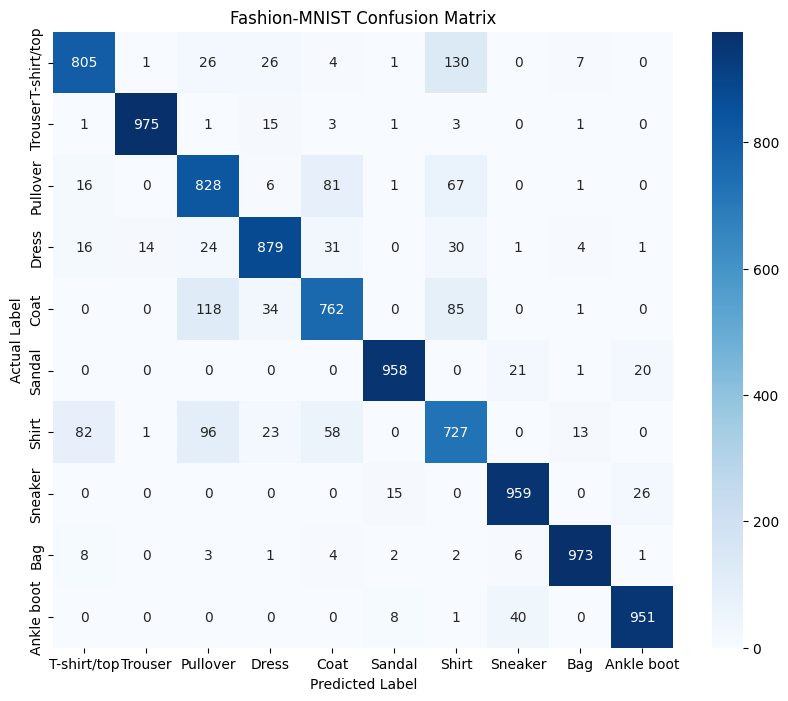

In [14]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

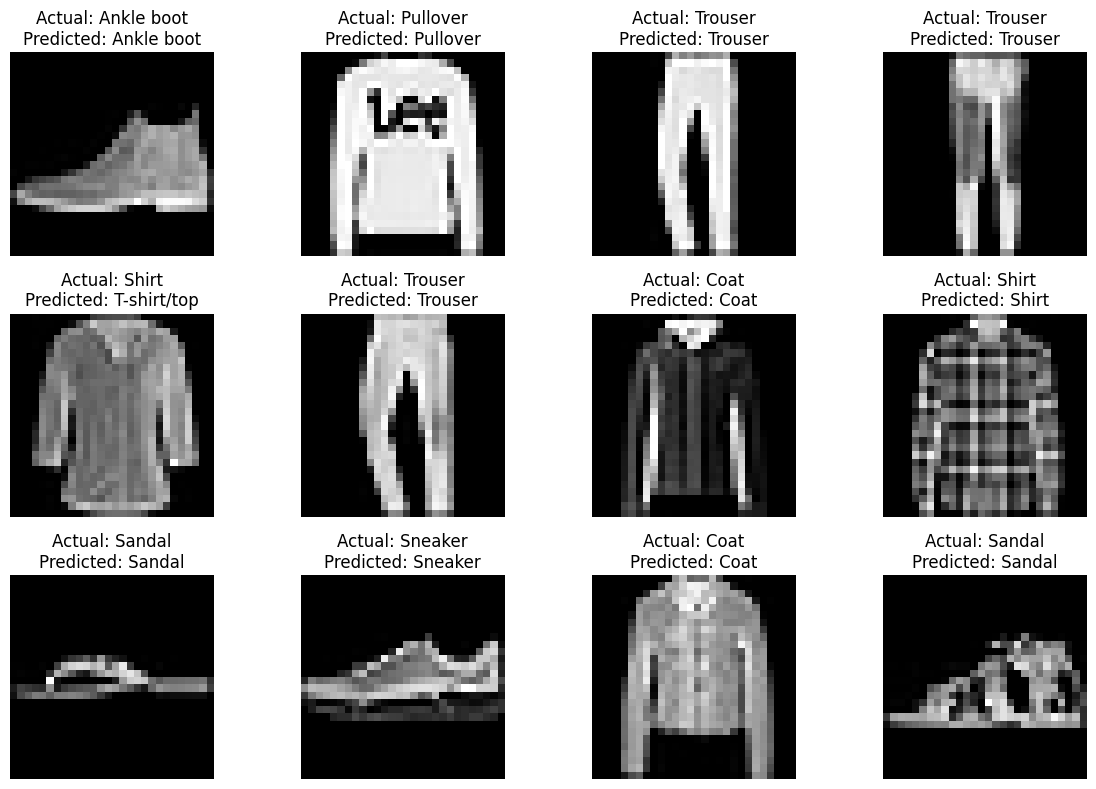

In [15]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i], cmap="gray")

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_labels[i]]

    plt.title("Actual: " + actual + "\nPredicted: " + predicted)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
correct_indices = np.where(predicted_labels == y_test)[0]
incorrect_indices = np.where(predicted_labels != y_test)[0]

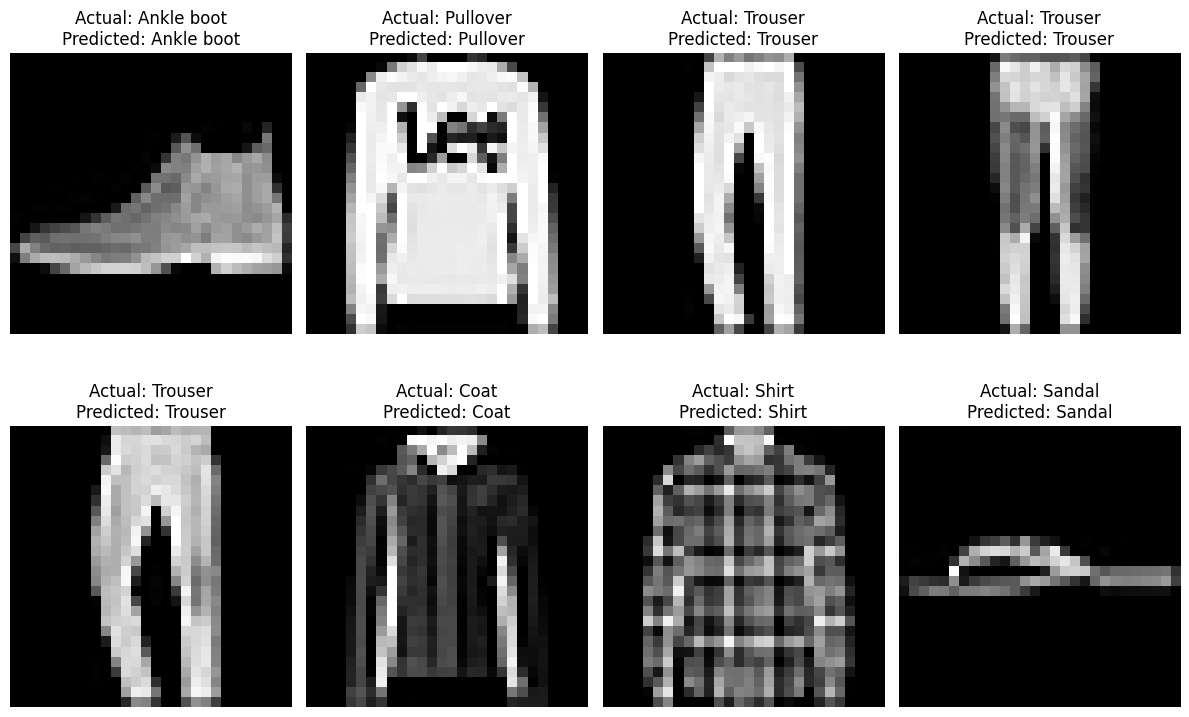

In [17]:
plt.figure(figsize=(12, 8))

for i in range(8):
    index = correct_indices[i]

    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title(
        "Actual: " + class_names[y_test[index]] +
        "\nPredicted: " + class_names[predicted_labels[index]]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

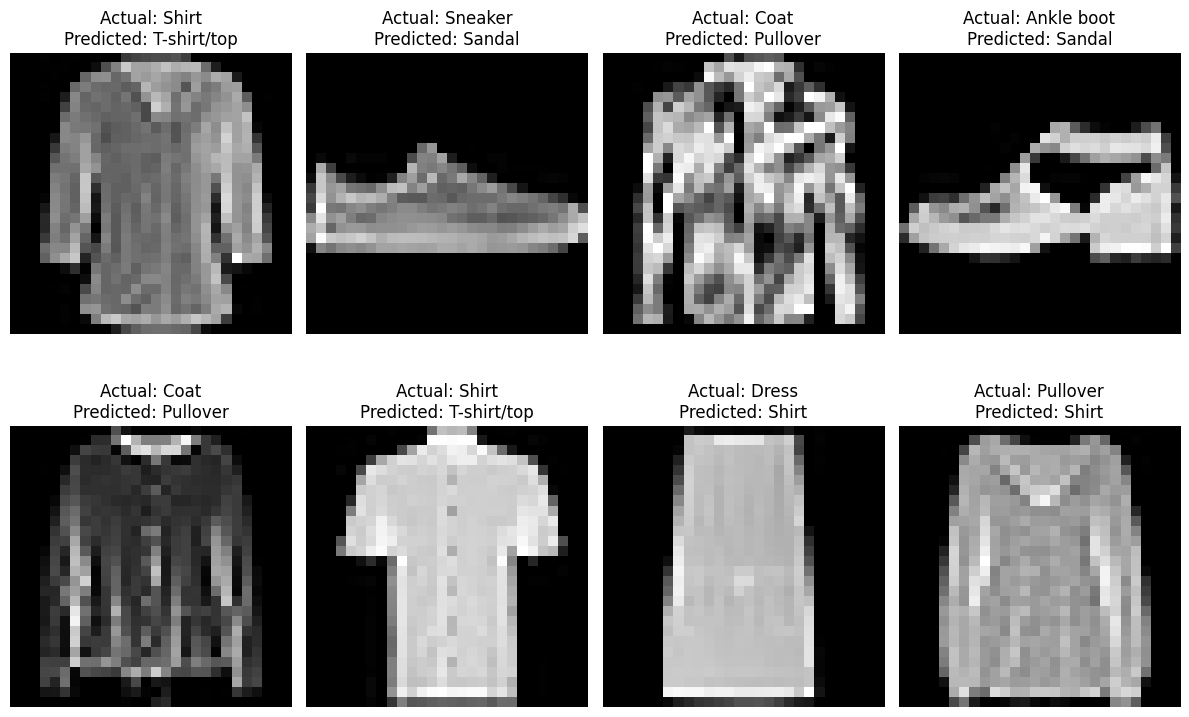

In [18]:
plt.figure(figsize=(12, 8))

for i in range(8):
    index = incorrect_indices[i]

    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title(
        "Actual: " + class_names[y_test[index]] +
        "\nPredicted: " + class_names[predicted_labels[index]]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

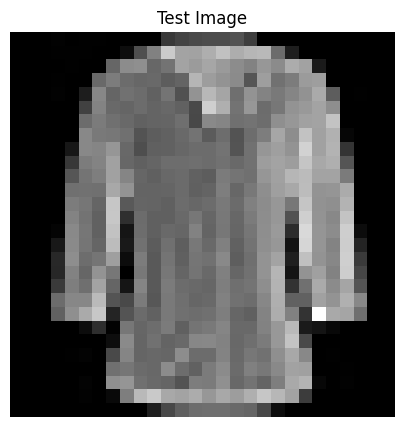

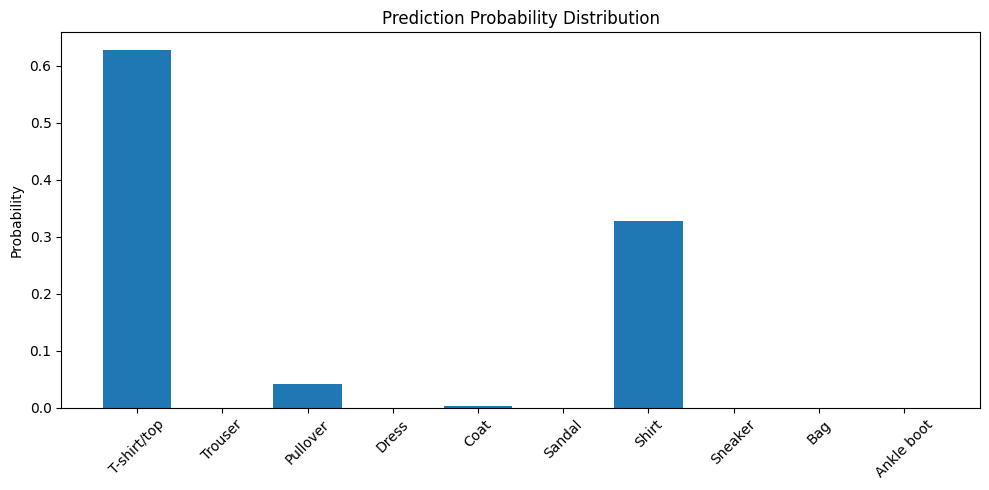

Actual label: Shirt
Predicted label: T-shirt/top


In [19]:
index = incorrect_indices[0]

plt.figure(figsize=(8, 5))
plt.imshow(x_test[index], cmap="gray")
plt.title("Test Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(class_names, predictions[index])
plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("Prediction Probability Distribution")
plt.tight_layout()
plt.show()

print("Actual label:", class_names[y_test[index]])
print("Predicted label:", class_names[predicted_labels[index]])